<a href="https://colab.research.google.com/github/madelinegilmore/machine_learning/blob/main/Madeline_Gilmore__notebook3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

peer review session 3

incomplete notebook, worked on completing it

In [ ]:
# code reuse session 1 - #1
# get library to load data
import pandas as pd

In [ ]:
#Loading data into a DataFrame
# code reuse session 1 - #2
data_frame = pd.read_csv("/content/drive/MyDrive/data science/cleaned_loan_approval_data.csv")

In [ ]:
# sample first 5 of dataset
# code reuse session 1 - #3

data_frame.head()

,Unnamed: 0,age,education_qualifications,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_loan_amount(allowed),credit_application_acceptance
0,3,40.0,Unknown,182004.0,RENT,3.0,EDUCATION,35000,8.00,0.19,N,11,approved,35000,0.0
1,4,40.0,Unknown,90000.0,MORTGAGE,3.0,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,approved,35000,0.0
2,5,40.0,Unknown,131004.0,MORTGAGE,9.0,VENTURE,30000,7.90,0.23,N,13,approved,30000,0.0
3,6,40.0,Unknown,150000.0,MORTGAGE,9.0,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,approved,25000,0.0
4,7,40.0,Unknown,132000.0,MORTGAGE,3.0,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,approved,25000,0.0


In [ ]:
# drop learnable parameters and unnecessary index-like variables, set target variable
# code reuse session 2 - #6


y = data_frame['credit_application_acceptance']
X = data_frame.drop(['credit_application_acceptance', 'loan_approval_status', 'max_loan_amount(allowed)', 'Unnamed: 0'], axis=1)   # all input features

In [ ]:
# encode string data
# code reuse session 1: # 25 & 26
# set as variables to use later for manual data input encoding

from sklearn import preprocessing

edu_encoder = preprocessing.LabelEncoder()
X['education_qualifications'] = edu_encoder.fit_transform(X['education_qualifications'])

home_encoder = preprocessing.LabelEncoder()
X['home_ownership'] = home_encoder.fit_transform(X['home_ownership'])

intent_encoder = preprocessing.LabelEncoder()
X['loan_intent'] = intent_encoder.fit_transform(X['loan_intent'])

default_encoder = preprocessing.LabelEncoder()
X['payment_default_on_file'] = default_encoder.fit_transform(X['payment_default_on_file'])

In [ ]:
# see list of attributes
# seminar 2, step 3

print(X.columns)

Index(['age', 'education_qualifications', 'income', 'home_ownership',
       'employment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate',
       'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length'],
      dtype='object')


In [ ]:
# see how many rows and colomns of x and y
# code resuse session 1, #6

print("x shape:" , X.shape)
print("y shape:" , y.shape)

x shape: (56405, 11)
y shape: (56405,)


In [ ]:
# split test data
# code reuse session 2 - 7,8

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [ ]:
# shape of each - week 3 tutorial: part 3, #4
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)

print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)

X_train shape (39483, 11)
X_test shape (16922, 11)
y_train shape (39483,)
y_test shape (16922,)


logistic regression model

In [ ]:
# scale input variables after train-test split to prevent data leakage
# week 3 tutorial: part 3, #3

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#instantiate log reg model using best params
# week 3 tutorial: part 3, #5

# import the class
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression(C=1, class_weight=None)
# Fit the model using the scaled training data
logreg.fit(X_train_scaled, y_train)
# Make predictions using the scaled test data
y_pred=logreg.predict(X_test_scaled)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

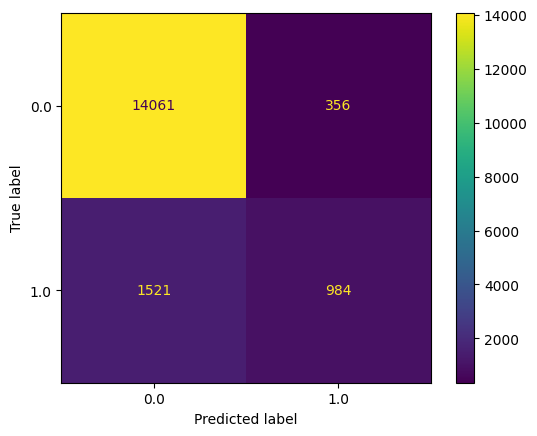

In [ ]:
# build confusion matrix to evaluate new parameter
# week 3 tutorial: part 3, #7

# import and plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Construct the confusion matrix cm
cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm,display_labels=logreg.classes_)
disp.plot()


              precision    recall  f1-score   support

         0.0       0.90      0.98      0.94     14417
         1.0       0.73      0.39      0.51      2505

    accuracy                           0.89     16922
   macro avg       0.82      0.68      0.72     16922
weighted avg       0.88      0.89      0.87     16922

Accuracy: 0.8890793050466848


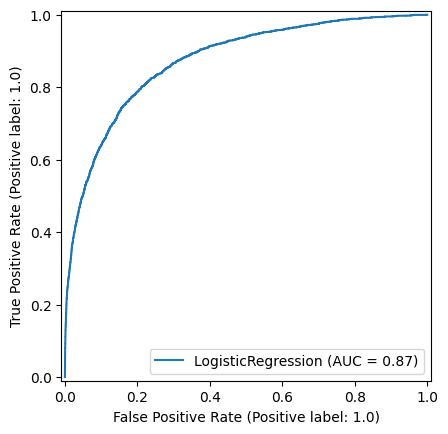

In [ ]:
# get classification report to evaluate new parameter
# week 4 notebook - step 8
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# get accuracy report for evaluation
# code reuse session 2: #12
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# get AUC-ROC report for evaluation
# code reuse session 3: #15
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(logreg, X_test_scaled, y_test)


# output is the same

KNN

optimize KNN - best model

In [ ]:
# week 4 seminar,  step 9
# Check KNN outcome with different weights

# Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier

knn2 = KNeighborsClassifier(n_neighbors = 10, weights='distance') # hyper paramerter

# Fit the KNN model using the scaled training data
knn2.fit(X_train_scaled, y_train)

# Make predictions using the scaled test data
y_pred=knn2.predict(X_test_scaled)

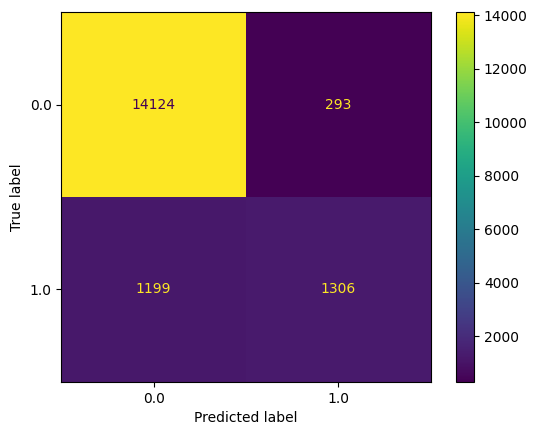

In [ ]:
# week 3 tutorial: part 3, #7



#Costruct the confusion matrix based on…
#comparing actual values (y_test) vs predicted (y_pred) in test data
cm_knn = confusion_matrix(y_test, y_pred, labels = knn2.classes_)

#Plot the confusion matrix
disp_knn_cm = ConfusionMatrixDisplay(cm_knn, display_labels=knn2.classes_)
disp_knn_cm.plot()



              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95     14417
         1.0       0.82      0.52      0.64      2505

    accuracy                           0.91     16922
   macro avg       0.87      0.75      0.79     16922
weighted avg       0.91      0.91      0.90     16922

Accuracy: 0.9118307528660915


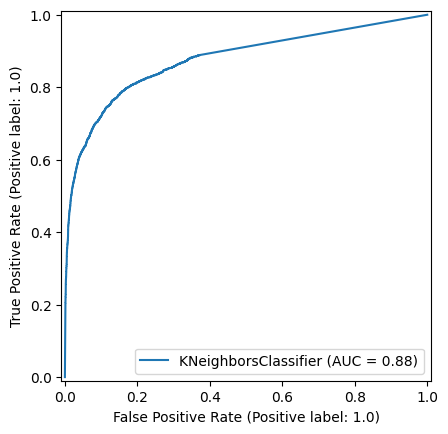

In [ ]:
# get classification report for evaluation (recall, precision, f1-score)
# week 4 notebook - step 8

print(classification_report(y_test, y_pred))

# get accuracy report for evaluation
# code reuse session 2: #12
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# get AUC-ROC report for evaluation
# code reuse session 3: #15
RocCurveDisplay.from_estimator(knn2, X_test_scaled, y_test)

Ensemble learner

In [ ]:
# tutorial 7 - hard voting step 1

#initiate a new ensemble model
from sklearn.ensemble import VotingClassifier

#create a dictionary of our base learner models
base_learners=[('LR', logreg), ('KNN', knn2)]

#create our voting classifier, inputting our models
ensemble_learner = VotingClassifier(base_learners, voting='soft')


In [ ]:
#fit model to training data
# tutorial 7 - hard voting step 1

ensemble_learner = ensemble_learner.fit(X_train, y_train)
y_pred_ensembler = ensemble_learner.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Evaluate your ensemble model by generating the classification report and the confusion matrix
# tutorial 7 - hard voting step 1

from sklearn.metrics import classification_report
print("Classification report for Ensmebler")
print(classification_report(y_test,y_pred_ensembler))

Classification report for Ensmebler
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94     14417
         1.0       0.78      0.43      0.55      2505

    accuracy                           0.90     16922
   macro avg       0.84      0.70      0.75     16922
weighted avg       0.89      0.90      0.88     16922



confusion_matrix for ensember learner


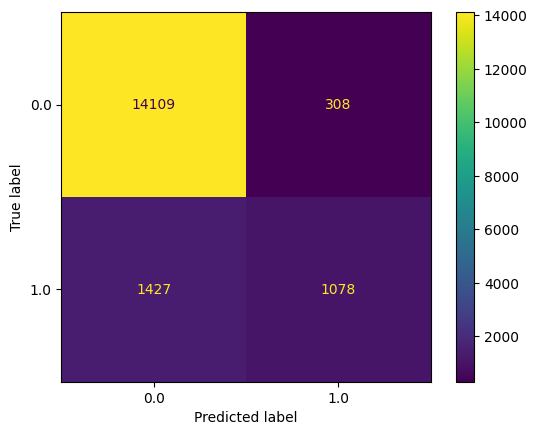

In [ ]:
# week 3 tutorial: part 3, #7

print("confusion_matrix for ensember learner")
ensemble_learner_cm=confusion_matrix(y_test,y_pred_ensembler)
disp=ConfusionMatrixDisplay(confusion_matrix=ensemble_learner_cm,display_labels = ensemble_learner.classes_)
disp.plot()

In [ ]:
# get classification report to evaluate new parameter
# week 4 notebook - step 8

print(classification_report(y_test, y_pred))

# get accuracy report for evaluation
# code reuse session 2: #12
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95     14417
         1.0       0.82      0.52      0.64      2505

    accuracy                           0.91     16922
   macro avg       0.87      0.75      0.79     16922
weighted avg       0.91      0.91      0.90     16922

Accuracy: 0.9118307528660915


Regression

In [ ]:
# code reuse session 1 - #1
# get library to load data
from pandas.core.api import DataFrame

#Loading data into a DataFrame
# code reuse session 1 - #2
df = pd.read_csv(r'/content/drive/MyDrive/data science/cleaned_loan_approval_data.csv')

In [ ]:
# see how many rows and colomns of x and y
# code resuse session 1, #6

df.shape

(56405, 15)

In [ ]:
#data_frame = data_frame.drop(['Unnamed: 0'], axis=1)
y = df['max_loan_amount(allowed)']
X = df.drop(['credit_application_acceptance', 'loan_approval_status', 'max_loan_amount(allowed)', 'Unnamed: 0'], axis=1)   # all input features
# encode string data
# code reuse session 1: # 25 & 26
# set as variables to use later for manual data input encoding

from sklearn import preprocessing

edu_encoder = preprocessing.LabelEncoder()
X['education_qualifications'] = edu_encoder.fit_transform(X['education_qualifications'])

home_encoder = preprocessing.LabelEncoder()
X['home_ownership'] = home_encoder.fit_transform(X['home_ownership'])

intent_encoder = preprocessing.LabelEncoder()
X['loan_intent'] = intent_encoder.fit_transform(X['loan_intent'])

default_encoder = preprocessing.LabelEncoder()
X['payment_default_on_file'] = default_encoder.fit_transform(X['payment_default_on_file'])

# approval_encoder = preprocessing.LabelEncoder()
# X['loan_approval_status'] = approval_encoder.fit_transform(X['loan_approval_status'])



In [ ]:
# see how many rows and colomns of x and y
# code resuse session 1, #6

print("x shape:" , X.shape)
print("y shape:" , y.shape)

x shape: (56405, 11)
y shape: (56405,)


In [ ]:
# split test data
# code reuse session 2 - 7,8
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [ ]:
# scale input variables after train-test split to prevent data leakage
# week 3 tutorial: part 3, #3

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# code resuse session 1, #5
# the list of the features’ names of your RETAINED data subset
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56405 entries, 0 to 56404
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     56405 non-null  int64  
 1   age                            56405 non-null  float64
 2   education_qualifications       56405 non-null  object 
 3   income                         56405 non-null  float64
 4   home_ownership                 56405 non-null  object 
 5   employment_length              56405 non-null  float64
 6   loan_intent                    56405 non-null  object 
 7   loan_amount                    56405 non-null  int64  
 8   loan_interest_rate             56405 non-null  float64
 9   loan_income_ratio              56405 non-null  float64
 10  payment_default_on_file        56405 non-null  object 
 11  credit_history_length          56405 non-null  int64  
 12  loan_approval_status           56405 non-null 

In [ ]:
# import regression tree
# code reuse session 3 - #6-9, 13

# import dt and metrits
from sklearn.tree import DecisionTreeRegressor

# make tree
dt1 = DecisionTreeRegressor(random_state=42)
dt1.fit(X_train, y_train)

# test tree
y_pred_dt1 = dt1.predict(X_test)

# import and measure metrix
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred_dt1))
print('MSE:', metrics.mean_squared_error(y_test, y_pred_dt1))
print('R2:', metrics.r2_score(y_test, y_pred_dt1))

MAE: 7565.263503132018
MSE: 501046714.83955795
R2: 0.7096497401216934


In [ ]:
#tutorial 6: part 2, step 3

# import plot and make tree visual
from matplotlib import pyplot as plt
from sklearn import tree
dt1_figure = plt.figure(figsize=(200,200))
DT_Graph = tree.plot_tree(dt1, feature_names=list(X_train.columns), class_names = ['0','1'], filled=True)

Error in callback <function _draw_all_if_interactive at 0x7fd7ee4e0b80> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7fd7ee4b6480> (for post_execute):


KeyboardInterrupt: 

In [ ]:
# import regression tree
# code reuse session 3 - #6-9, 13

dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)

# make tree
dt2.fit(X_train, y_train)


# test tree
y_pred_dt2 = dt2.predict(X_test)


# import and measure metrix
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred_dt2))
print('MSE:', metrics.mean_squared_error(y_test, y_pred_dt2))
print('R2:', metrics.r2_score(y_test, y_pred_dt2))


In [ ]:
#tutorial 6: part 2, step 3

# import plot and make tree visual

dt2_figure = plt.figure(figsize=(200,200))
DT_Graph = tree.plot_tree(dt2, feature_names=list(X_train.columns), class_names = ['0','1'], filled=True)

In [ ]:
# save the figures as high quality images
#tutorial 6: part 2, step 3

dt2_figure.savefig("pruned_tree.svg")
dt1_figure.savefig("unpruned_tree.svg")

KeyboardInterrupt: 

In [ ]:
# tutorial 7 - part 5

# make empty data array
data = []

# add client details as map
new_client = {
    'age': 56,
    'education_qualifications': edu_encoder.transform(['Unknown'])[0],
    'income': 57000,
    'home_ownership': home_encoder.transform(['RENT'])[0],
    'employment_length': 15,
    'loan_intent': intent_encoder.transform(['MEDICAL'])[0],
    'loan_amount': 25700,
    'loan_interest_rate': 23,
    'loan_income_ratio': 10,
    'payment_default_on_file': default_encoder.transform(['N'])[0],
    'credit_history_length': 35
}

# add client to data array
data.append(new_client)

# make data frame
data2 = pd.DataFrame(data)


# proceed with prediction
prediction = dt2.predict(data2)

# display prediction
print(prediction)


[2350.90840841]
